In [4]:
import pandas as pd
import matplotlib.pyplot as plt

import os
import numpy as np
import pandas as pd
from PIL import Image
from tqdm import tqdm

# Loading Dataset

In [5]:
df = pd.read_parquet("hf://datasets/CrashVisionAITeam/CrashedDB/parquets/CIREN/ciren_training_manifest.parquet")


/anaconda3/envs/VelocityEstimationAI/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [6]:
print(df.head())

                                        image_id  cirenId  caseId  \
0  ciren_11_52-kmph-32-mph_4-Severe_001_Vehicle1       11    8392   
1  ciren_11_52-kmph-32-mph_4-Severe_002_Vehicle1       11    8392   
2  ciren_11_52-kmph-32-mph_4-Severe_003_Vehicle1       11    8392   
3  ciren_11_52-kmph-32-mph_4-Severe_004_Vehicle1       11    8392   
4  ciren_11_52-kmph-32-mph_4-Severe_005_Vehicle1       11    8392   

                                       image_relpath  \
0  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   
1  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   
2  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   
3  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   
4  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   

                             image_filename  vehicleNumber  image_sequence  \
0  52-kmph-32-mph_4-Severe_001_Vehicle1.jpg              1               1   
1  52-kmph-32-mph_4-Severe_002_Vehicle1.jpg              1               2   
2  52-kmph-32-

# EDA

In [7]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5737 entries, 0 to 5736
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   image_id                5737 non-null   object
 1   cirenId                 5737 non-null   Int64 
 2   caseId                  5737 non-null   Int64 
 3   image_relpath           5737 non-null   object
 4   image_filename          5737 non-null   object
 5   vehicleNumber           5737 non-null   Int64 
 6   image_sequence          5737 non-null   Int64 
 7   photoId                 5737 non-null   Int64 
 8   objectID                5737 non-null   object
 9   description             5737 non-null   object
 10  subtype                 5737 non-null   object
 11  mais                    5737 non-null   object
 12  totalDeltaVKph          4559 non-null   Int64 
 13  totalDeltaVMph          4559 non-null   Int64 
 14  cdc                     5737 non-null   object
 15  cloc

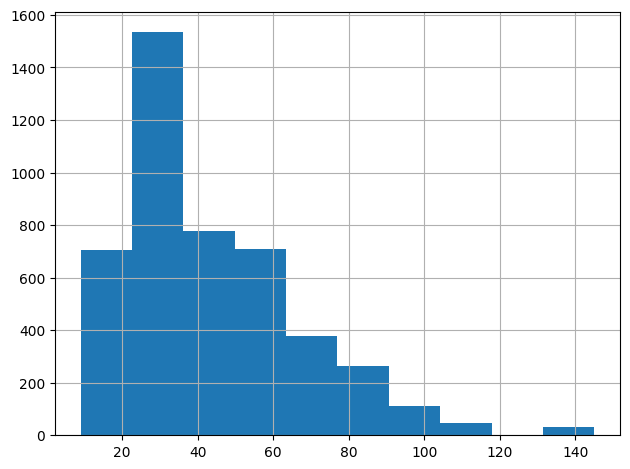

In [8]:
df["totalDeltaVKph"].hist()
plt.tight_layout()
plt.show()

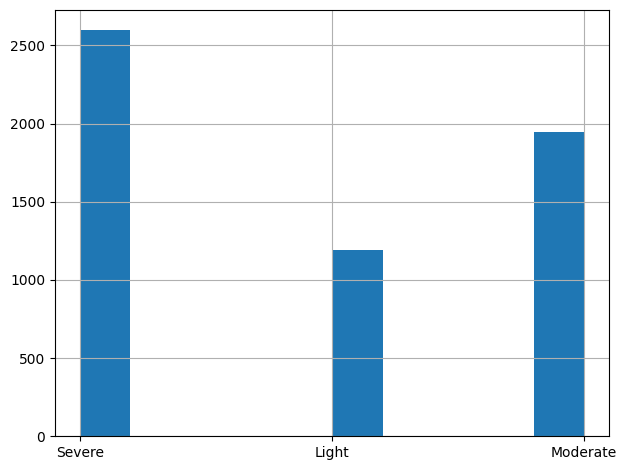

In [9]:
df["severityDescription"].hist()
plt.tight_layout()
plt.show()

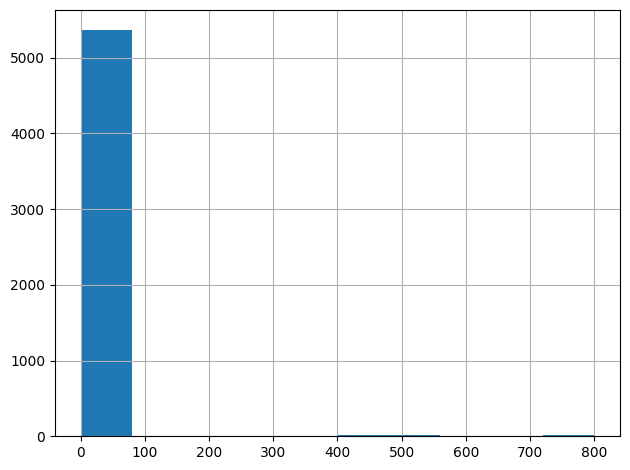

In [10]:
df["cargoWeightKg"].hist()
plt.tight_layout()
plt.show()

# Path Columns Inspection

In [11]:
df["image_filename"][0]

'52-kmph-32-mph_4-Severe_001_Vehicle1.jpg'

In [12]:
df["image_relpath"][0]

'utils/Preprocessing/NHTSADatabaseExtraction/Extraction/Images/CIREN/11/52-kmph-32-mph_4-Severe_001_Vehicle1.jpg'

# Image Inspection

## Aux Dataframe Creation for Image Feature Analysis

In [13]:
BASE_PATH = "../../../"  


features = []

for rel_path in tqdm(df["image_relpath"]):

    full_path = os.path.join(BASE_PATH, rel_path)

    try:
        with Image.open(full_path) as img:

            # Basic info
            width, height = img.size
            mode = img.mode

            # Num channels
            channels = len(img.getbands())

            # Aspect ratio
            aspect_ratio = width / height

            # Orientation
            if width > height:
                orientation = "landscape"
            elif height > width:
                orientation = "portrait"
            else:
                orientation = "square"

            # File size
            file_size_kb = os.path.getsize(full_path) / 1024

            # Convert to numpy
            img_np = np.array(img)

            # Brightness
            brightness = img_np.mean()

            # Contrast
            contrast = img_np.std()

            features.append({
                "image_relpath": rel_path,
                "width": width,
                "height": height,
                "aspect_ratio": aspect_ratio,
                "channels": channels,
                "mode": mode,
                "orientation": orientation,
                "file_size_kb": file_size_kb,
                "brightness": brightness,
                "contrast": contrast
            })

    except Exception as e:
        print(f"Error with {rel_path}: {e}")

# Create DF
image_stats_df = pd.DataFrame(features)

# Save as csv
df.to_csv('../CSV/ciren_training_image_stats.csv', index=False)

print(image_stats_df.head())

100%|██████████| 5737/5737 [04:39<00:00, 20.51it/s] 

                                       image_relpath  width  height  \
0  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   2000    1500   
1  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   2000    1500   
2  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   2000    1500   
3  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   2000    1500   
4  utils/Preprocessing/NHTSADatabaseExtraction/Ex...   2000    1500   

   aspect_ratio  channels mode orientation  file_size_kb  brightness  \
0      1.333333         3  RGB   landscape   1604.840820  113.319504   
1      1.333333         3  RGB   landscape   1425.194336  134.149621   
2      1.333333         3  RGB   landscape   1509.133789  120.514304   
3      1.333333         3  RGB   landscape   1556.234375  104.812883   
4      1.333333         3  RGB   landscape   1550.423828  139.100602   

    contrast  
0  69.640534  
1  78.655606  
2  74.110133  
3  72.267655  
4  62.389866  


## Image Analysis

In [14]:
print(image_stats_df[["width", "height"]].describe())

             width       height
count  5737.000000  5737.000000
mean   1948.804079  1583.058916
std     824.892867   697.930117
min     240.000000   216.000000
25%    1440.000000  1080.000000
50%    1728.000000  1600.000000
75%    2592.000000  1920.000000
max    6000.000000  6000.000000


In [15]:
gray_images = image_stats_df[
    image_stats_df["channels"] == 1
]

print("Gray-Images: ",len(gray_images))

Gray-Images:  0


In [16]:
image_stats_df["orientation"].value_counts()

orientation
landscape    4500
portrait     1236
square          1
Name: count, dtype: int64

WIDTH
Mean: 1948.8040787868224
Median: 1728.0


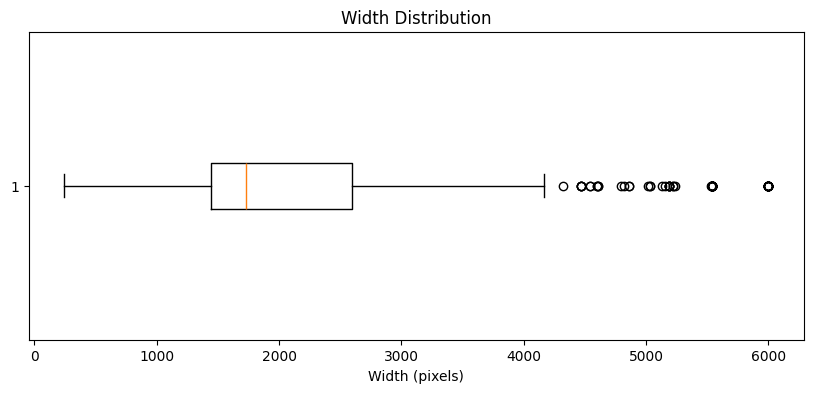


HEIGHT
Mean: 1583.0589158096566
Median: 1600.0


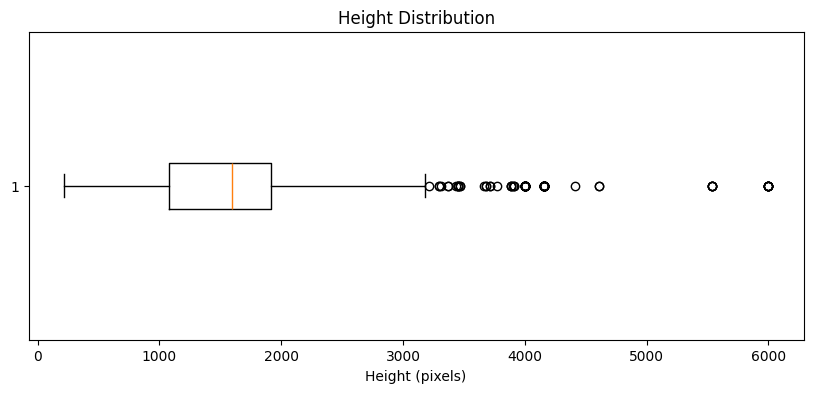

In [20]:
print("WIDTH")
print("Mean:", image_stats_df["width"].mean())
print("Median:", image_stats_df["width"].median())

# WIDTH BOXPLOT
plt.figure(figsize=(10, 4))
plt.boxplot(
    image_stats_df["width"],
    vert=False
)
plt.title("Width Distribution")
plt.xlabel("Width (pixels)")
plt.show()


print("\nHEIGHT")
print("Mean:", image_stats_df["height"].mean())
print("Median:", image_stats_df["height"].median())

# HEIGHT BOXPLOT
plt.figure(figsize=(10, 4))
plt.boxplot(
    image_stats_df["height"],
    vert=False
)
plt.title("Height Distribution")
plt.xlabel("Height (pixels)")
plt.show()

In [21]:
means = []
stds = []

for rel_path in tqdm(df["image_relpath"]):

    full_path = os.path.join(BASE_PATH, rel_path)

    try:
        img = Image.open(full_path).convert("RGB")
        img = np.array(img) / 255.0

        means.append(img.mean(axis=(0,1)))
        stds.append(img.std(axis=(0,1)))

    except:
        pass

mean = np.mean(means, axis=0)
std = np.mean(stds, axis=0)

print("Mean:", mean)
print("Std:", std)

100%|██████████| 5737/5737 [16:14<00:00,  5.89it/s]  

Mean: [0.51322499 0.49685384 0.49083403]
Std: [0.26715419 0.26588872 0.26546267]


# Save Dataset Manifest as CSV for Torch DataLoader

In [ ]:
df.to_csv('../CSV/ciren_training_manifest.csv', index=False)